In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("cleaned_employees.csv")

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
   Employee_ID Employee_Name Department  Age  Salary Joining_Date
0          101         Alice         HR   29   45000   2021-01-15
1          102           Bob         IT   34   85000   2020-06-10
2          103       Charlie    Finance   41   72000   2019-03-20
3          104         David      Sales   30   58000   2022-08-01
4          105           Eva         IT   27   91000   2023-02-14


In [3]:
print("\nDataset Information")
print(df.info())

print("\nShape:", df.shape)

print("\nColumns")
print(df.columns)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Employee_ID    8 non-null      int64 
 1   Employee_Name  8 non-null      object
 2   Department     8 non-null      object
 3   Age            8 non-null      int64 
 4   Salary         8 non-null      int64 
 5   Joining_Date   8 non-null      object
dtypes: int64(3), object(3)
memory usage: 516.0+ bytes
None

Shape: (8, 6)

Columns
Index(['Employee_ID', 'Employee_Name', 'Department', 'Age', 'Salary',
       'Joining_Date'],
      dtype='object')


In [4]:
# Missing values
print(df.isnull().sum())

if df.isnull().sum().sum() > 0:

    df["Salary"].fillna(df["Salary"].mean(), inplace=True)

    df["Age"].fillna(df["Age"].median(), inplace=True)

    df["Department"].fillna(df["Department"].mode()[0], inplace=True)

    print("Missing values filled")

else:

    print("No missing values found")


# Duplicate records
duplicates = df.duplicated().sum()

if duplicates > 0:

    df.drop_duplicates(inplace=True)

    print("Duplicates removed")

else:

    print("No duplicate records")

Employee_ID      0
Employee_Name    0
Department       0
Age              0
Salary           0
Joining_Date     0
dtype: int64
No missing values found
No duplicate records


In [5]:
df["Joining_Date"] = pd.to_datetime(df["Joining_Date"])

df["Joining_Year"] = df["Joining_Date"].dt.year

print(df.head())

   Employee_ID Employee_Name Department  Age  Salary Joining_Date  \
0          101         Alice         HR   29   45000   2021-01-15   
1          102           Bob         IT   34   85000   2020-06-10   
2          103       Charlie    Finance   41   72000   2019-03-20   
3          104         David      Sales   30   58000   2022-08-01   
4          105           Eva         IT   27   91000   2023-02-14   

   Joining_Year  
0          2021  
1          2020  
2          2019  
3          2022  
4          2023  


In [6]:
salary_level = []

for salary in df["Salary"]:

    if salary >= 90000:
        salary_level.append("High")

    elif salary >= 70000:
        salary_level.append("Medium")

    else:
        salary_level.append("Low")

df["Salary_Level"] = salary_level

print(df[["Employee_Name","Salary","Salary_Level"]])

  Employee_Name  Salary Salary_Level
0         Alice   45000          Low
1           Bob   85000       Medium
2       Charlie   72000       Medium
3         David   58000          Low
4           Eva   91000         High
5         Frank   60000          Low
6         Grace   78000       Medium
7         Henry   62000          Low


In [8]:
bonus = []

for salary in df["Salary"]:

    if salary >= 80000:
        bonus.append(salary * 0.20)

    elif salary >= 60000:
        bonus.append(salary * 0.15)

    else:
        bonus.append(salary * 0.10)

df["Bonus"] = bonus

df["TotalSalary"] = df["Salary"] + df["Bonus"]

In [9]:
department_summary = df.groupby("Department").agg({

    "Salary":["mean","max","min"],

    "Age":"mean",

    "Employee_ID":"count"

})

print(department_summary)

             Salary                 Age Employee_ID
               mean    max    min  mean       count
Department                                         
Finance     75000.0  78000  72000  43.0           2
HR          52500.0  60000  45000  33.5           2
IT          88000.0  91000  85000  30.5           2
Sales       60000.0  62000  58000  30.5           2


In [10]:
year_summary = df.groupby("Joining_Year")["Salary"].mean()

print(year_summary)

Joining_Year
2017    78000.0
2018    60000.0
2019    72000.0
2020    85000.0
2021    53500.0
2022    58000.0
2023    91000.0
Name: Salary, dtype: float64


In [11]:
highest = df.loc[df["Salary"].idxmax()]

lowest = df.loc[df["Salary"].idxmin()]

print("\nHighest Salary Employee")
print(highest)

print("\nLowest Salary Employee")
print(lowest)


Highest Salary Employee
Employee_ID                      105
Employee_Name                    Eva
Department                        IT
Age                               27
Salary                         91000
Joining_Date     2023-02-14 00:00:00
Joining_Year                    2023
Salary_Level                    High
Bonus                        18200.0
TotalSalary                 109200.0
Name: 4, dtype: object

Lowest Salary Employee
Employee_ID                      101
Employee_Name                  Alice
Department                        HR
Age                               29
Salary                         45000
Joining_Date     2021-01-15 00:00:00
Joining_Year                    2021
Salary_Level                     Low
Bonus                         4500.0
TotalSalary                  49500.0
Name: 0, dtype: object


In [13]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.20,random_state=42)

model = LinearRegression()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)

print("Mean Absolute Error =", mae)

Mean Absolute Error = 13053.191489361692


In [14]:
df.to_csv("Market_Trend_Analysis.csv",index=False)

department_summary.to_csv("Department_Report.csv")

year_summary.to_csv("Yearly_Salary_Trend.csv")

In [15]:
print("="*60)
print("ALGORITHMIC MARKET TREND ANALYZER REPORT")
print("="*60)

print("Total Employees :",len(df))
print("Departments :",df["Department"].nunique())

print("Average Salary :",df["Salary"].mean())
print("Maximum Salary :",df["Salary"].max())
print("Minimum Salary :",df["Salary"].min())

print("\nPrediction for Year 2027")
print(prediction[0])

print("\nProject Completed Successfully")

ALGORITHMIC MARKET TREND ANALYZER REPORT
Total Employees : 8
Departments : 4
Average Salary : 68875.0
Maximum Salary : 91000
Minimum Salary : 45000

Prediction for Year 2027
69142.85714285714

Project Completed Successfully


        ALGORITHMIC MARKET TREND ANALYZER

Dataset Loaded Successfully.

First Five Records
   Employee_ID Employee_Name Department  Age  Salary Joining_Date
0          101         Alice         HR   29   45000   2021-01-15
1          102           Bob         IT   34   85000   2020-06-10
2          103       Charlie    Finance   41   72000   2019-03-20
3          104         David      Sales   30   58000   2022-08-01
4          105           Eva         IT   27   91000   2023-02-14

Last Five Records
   Employee_ID Employee_Name Department  Age  Salary Joining_Date
3          104         David      Sales   30   58000   2022-08-01
4          105           Eva         IT   27   91000   2023-02-14
5          106         Frank         HR   38   60000   2018-11-05
6          107         Grace    Finance   45   78000   2017-09-18
7          108         Henry      Sales   31   62000   2021-12-11

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data col

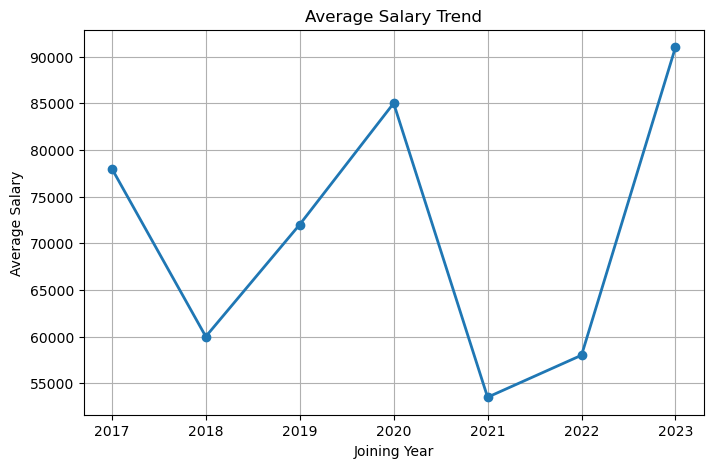

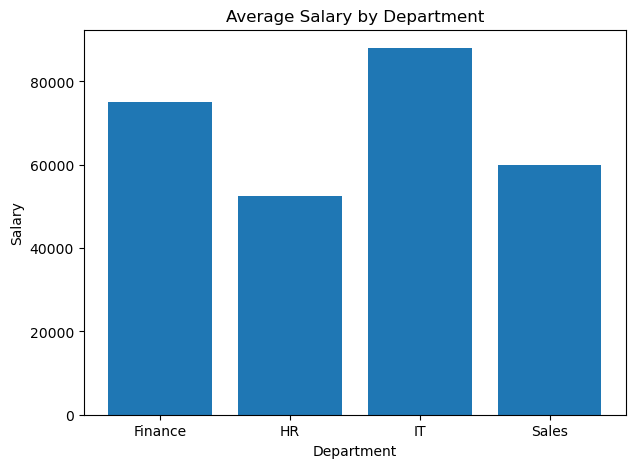


Predicted Average Salary for 2027
64070.92

Model Evaluation
Mean Absolute Error : 13053.19
R2 Score : -0.19


              PROJECT REPORT
Project Name : Algorithmic Market Trend Analyzer

Dataset Statistics
----------------------------
Total Employees : 8
Departments : 4
Average Salary : 68875.0
Maximum Salary : 91000
Minimum Salary : 45000

Data Cleaning
----------------------------
✓ No Missing Values
✓ No Duplicate Records
✓ Date Format Converted
✓ Bonus Calculated
✓ Experience Calculated
✓ Salary Grade Assigned

Analysis Completed
----------------------------
✓ Department-wise Salary Analysis
✓ Year-wise Salary Trend
✓ Highest Paid Employee
✓ Lowest Paid Employee
✓ Future Salary Prediction

Generated Files
----------------------------
1. Market_Trend_Analysis.csv
2. Department_Report.csv
3. Yearly_Salary_Report.csv

Project Completed Successfully


In [16]:
# ==========================================================
# Project Title : Algorithmic Market Trend Analyzer
# Complexity    : Easy
# Author        : Your Name
# Description   :
# This project analyzes historical employee salary data to
# identify trends, clean the dataset, visualize salary
# patterns, and predict future salary using Linear Regression.
# ==========================================================

# ===========================
# Import Required Libraries
# ===========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# ===========================
# STEP 1 : Load Dataset
# ===========================

print("="*70)
print("        ALGORITHMIC MARKET TREND ANALYZER")
print("="*70)

try:
    df = pd.read_csv("cleaned_employees.csv")
    print("\nDataset Loaded Successfully.")
except FileNotFoundError:
    print("Dataset not found.")
    exit()

# ===========================
# STEP 2 : Display Dataset
# ===========================

print("\nFirst Five Records")
print(df.head())

print("\nLast Five Records")
print(df.tail())

# ===========================
# STEP 3 : Dataset Information
# ===========================

print("\nDataset Information")
print(df.info())

print("\nShape :", df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nSummary Statistics")
print(df.describe())

# ===========================
# STEP 4 : Missing Value Check
# ===========================

print("\nChecking Missing Values")

missing = df.isnull().sum()

print(missing)

if missing.sum() > 0:

    print("\nMissing values found.")

    if "Salary" in df.columns:
        df["Salary"].fillna(df["Salary"].mean(), inplace=True)

    if "Age" in df.columns:
        df["Age"].fillna(df["Age"].median(), inplace=True)

    if "Department" in df.columns:
        df["Department"].fillna(df["Department"].mode()[0], inplace=True)

    print("Missing values filled.")

else:

    print("No Missing Values.")

# ===========================
# STEP 5 : Duplicate Check
# ===========================

duplicates = df.duplicated().sum()

print("\nDuplicate Records :", duplicates)

if duplicates > 0:

    df.drop_duplicates(inplace=True)

    print("Duplicate Records Removed.")

else:

    print("Dataset Already Clean.")

# ===========================
# STEP 6 : Convert Date
# ===========================

df["Joining_Date"] = pd.to_datetime(df["Joining_Date"])

df["Joining_Year"] = df["Joining_Date"].dt.year

# ===========================
# STEP 7 : Salary Grade
# ===========================

salary_grade = []

for salary in df["Salary"]:

    if salary >= 90000:
        salary_grade.append("A")

    elif salary >= 70000:
        salary_grade.append("B")

    elif salary >= 50000:
        salary_grade.append("C")

    else:
        salary_grade.append("D")

df["Salary_Grade"] = salary_grade

# ===========================
# STEP 8 : Bonus Calculation
# ===========================

bonus = []

for salary in df["Salary"]:

    if salary >= 80000:

        bonus.append(salary * 0.20)

    elif salary >= 60000:

        bonus.append(salary * 0.15)

    else:

        bonus.append(salary * 0.10)

df["Bonus"] = bonus

df["Total_Salary"] = df["Salary"] + df["Bonus"]

# ===========================
# STEP 9 : Experience
# ===========================

current_year = 2026

df["Experience"] = current_year - df["Joining_Year"]

# ===========================
# STEP 10 : Filtering
# ===========================

print("\nEmployees Salary Above 60000")

high_salary = df[df["Salary"] > 60000]

print(high_salary)

# ===========================
# STEP 11 : Department Summary
# ===========================

department_summary = df.groupby("Department").agg({

    "Salary":["mean","max","min","sum"],

    "Bonus":"sum",

    "Experience":"mean",

    "Employee_ID":"count"

})

print("\nDepartment Summary")

print(department_summary)

# ===========================
# STEP 12 : Yearly Salary Trend
# ===========================

yearly_salary = df.groupby("Joining_Year")["Salary"].mean()

print("\nAverage Salary by Joining Year")

print(yearly_salary)

# ===========================
# STEP 13 : Highest Salary
# ===========================

highest = df.loc[df["Salary"].idxmax()]

print("\nHighest Paid Employee")

print(highest)

# ===========================
# STEP 14 : Lowest Salary
# ===========================

lowest = df.loc[df["Salary"].idxmin()]

print("\nLowest Paid Employee")

print(lowest)

# ===========================
# STEP 15 : Data Visualization
# ===========================

plt.figure(figsize=(8,5))

plt.plot(yearly_salary.index,
         yearly_salary.values,
         marker="o",
         linewidth=2)

plt.title("Average Salary Trend")

plt.xlabel("Joining Year")

plt.ylabel("Average Salary")

plt.grid(True)

plt.show()

# Department Salary

department_avg = df.groupby("Department")["Salary"].mean()

plt.figure(figsize=(7,5))

plt.bar(department_avg.index,
        department_avg.values)

plt.title("Average Salary by Department")

plt.xlabel("Department")

plt.ylabel("Salary")

plt.show()

# ===========================
# STEP 16 : Machine Learning
# ===========================

X = df[["Joining_Year"]]

y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

model = LinearRegression()

model.fit(X_train,y_train)

# ===========================
# STEP 17 : Prediction
# ===========================

future_year = pd.DataFrame({"Joining_Year":[2027]})

future_salary = model.predict(future_year)

print("\nPredicted Average Salary for 2027")

print(round(future_salary[0],2))

# ===========================
# STEP 18 : Accuracy
# ===========================

prediction = model.predict(X_test)

mae = mean_absolute_error(y_test,prediction)

r2 = r2_score(y_test,prediction)

print("\nModel Evaluation")

print("Mean Absolute Error :", round(mae,2))

print("R2 Score :", round(r2,2))

# ===========================
# STEP 19 : Save Files
# ===========================

df.to_csv("Market_Trend_Analysis.csv",index=False)

department_summary.to_csv("Department_Report.csv")

yearly_salary.to_csv("Yearly_Salary_Report.csv")

# ===========================
# STEP 20 : Final Report
# ===========================

print("\n")
print("="*70)
print("              PROJECT REPORT")
print("="*70)

print("Project Name : Algorithmic Market Trend Analyzer")

print("\nDataset Statistics")

print("----------------------------")

print("Total Employees :",len(df))

print("Departments :",df["Department"].nunique())

print("Average Salary :",round(df["Salary"].mean(),2))

print("Maximum Salary :",df["Salary"].max())

print("Minimum Salary :",df["Salary"].min())

print("\nData Cleaning")

print("----------------------------")

if missing.sum()==0:
    print("✓ No Missing Values")

else:
    print("✓ Missing Values Filled")

if duplicates==0:
    print("✓ No Duplicate Records")

else:
    print("✓ Duplicate Records Removed")

print("✓ Date Format Converted")

print("✓ Bonus Calculated")

print("✓ Experience Calculated")

print("✓ Salary Grade Assigned")

print("\nAnalysis Completed")

print("----------------------------")

print("✓ Department-wise Salary Analysis")

print("✓ Year-wise Salary Trend")

print("✓ Highest Paid Employee")

print("✓ Lowest Paid Employee")

print("✓ Future Salary Prediction")

print("\nGenerated Files")

print("----------------------------")

print("1. Market_Trend_Analysis.csv")

print("2. Department_Report.csv")

print("3. Yearly_Salary_Report.csv")

print("\nProject Completed Successfully")

print("="*70)